# Análisis modular del TP1

Este notebook ejecuta el flujo de análisis por celdas y es compatible con VS Code, Jupyter y Google Colab.

**Archivo de entrada:** `datos_TP1_2025.csv`

## 1. Crear el notebook y seleccionar el kernel

En VS Code o Colab, seleccioná un kernel de Python válido antes de ejecutar las celdas. Los resultados quedarán embebidos en este archivo `.ipynb`.

## 2. Instalar y validar dependencias

Ejecutá esta celda solo si el entorno no tiene `pandas` o `matplotlib` instalados. En Google Colab normalmente ya están disponibles.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tp1.utils import *
from tp1.eda import *

## 3. Cargar los datos

La ruta relativa funciona tanto en la carpeta local del proyecto como después de subir el archivo a Colab.

In [2]:
OUTPUT_DIR = Path("outputs")

dataset = cargar_pickle("outputs/dataset_cleaned.pkl")
dataset.head()

Archivo pickle cargado desde: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_cleaned.pkl


,estudios_maximos,estado_civil,modo_aplicacion,is_masculino,is_desplazado,is_desercion,carrera,is_asistencia_diurna,cualificacion_promedio,puntaje_ingreso,...,uc_inscritos_segundo_semestre,cant_eval_segundo_semestre,uc_aprobadas_segundo_semestre,nota_promedio_segundo_semestre,demanda_cog_padre,demanda_cog_madre,ingresos_padre,ingresos_madre,estado_civil_id,estado_civil_desc
0,Educación Secundaria,1 - Soltero,Acceso General,0,0,Desertor,Derecho,1,66,65,...,6,7,6,62,Demanda cognitiva media,Demanda cognitiva media,Ingresos medios-bajos,Ingresos medios-bajos,1,Soltero
1,Educación Secundaria,1 - Soltero,Acceso por Normativa Específica,0,1,En Curso,Enfermería,1,69,66,...,8,11,7,64,Muy alta demanda cognitiva,Muy alta demanda cognitiva,Altos ingresos,Altos ingresos,1,Soltero
2,Educación Secundaria,1 - Soltero,Acceso por Normativa Específica,0,1,Desertor,Enfermería,1,69,63,...,7,12,6,65,Muy baja demanda cognitiva,Muy baja demanda cognitiva,Bajos ingresos,Bajos ingresos,1,Soltero
3,Superior - Pregrado,1 - Soltero,Acceso General,0,1,Desertor,Economía,1,68,68,...,5,8,5,66,Muy baja demanda cognitiva,Muy baja demanda cognitiva,Bajos ingresos,Bajos ingresos,1,Soltero
4,Educación Secundaria,1 - Soltero,Acceso General,1,1,Desertor,Periodismo y Comunicación,1,68,70,...,6,6,6,68,Demanda cognitiva media,Demanda cognitiva media,Ingresos medios-bajos,Ingresos medios-bajos,1,Soltero


In [3]:
dataset.dtypes

estudios_maximos                        object
estado_civil                            object
modo_aplicacion                         object
is_masculino                             int64
is_desplazado                            int64
is_desercion                            object
carrera                                 object
is_asistencia_diurna                     int64
cualificacion_promedio                   int64
puntaje_ingreso                          int64
is_necesidades_educativas_especiales    object
is_deuda                                object
is_matricula_al_dia                     object
is_beca                                 object
edad_inscripcion                         int64
is_estudiante_internacional             object
uc_inscritos_primer_semestre             int64
cant_eval_primer_semestre                int64
uc_aprobadas_primer_semestre             int64
nota_promedio_primer_semestre            int64
uc_inscritos_segundo_semestre            int64
cant_eval_seg

In [4]:
estadisticas_numericas = calcular_estadisticas_numericas(dataset)
estadisticas_numericas

,N,N Miss,Missing,Zeros,Positivos,Negativos,min,max,mean,p_0.01,p_0.05,p_0.25,p_0.5,p_0.75,p_0.95,p_0.99,std,Coeff of Variation
is_masculino,57510,0,0.0,43760,13750,0,0,1,0.239089,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.426531,1.783985
is_desplazado,57510,0,0.0,22636,34874,0,0,1,0.606399,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.488552,0.805662
is_asistencia_diurna,57510,0,0.0,3945,53565,0,0,1,0.931403,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.252769,0.271386
cualificacion_promedio,57510,0,0.0,0,57510,0,50,97,69.796974,55.09,61.0,66.0,70.0,74.0,79.0,84.0,5.788817,0.082938
puntaje_ingreso,57510,0,0.0,0,57510,0,50,100,66.33349,53.0,57.0,63.0,66.0,70.0,78.0,84.0,6.218462,0.093745
edad_inscripcion,57510,0,0.0,0,57510,0,17,70,21.108503,18.0,18.0,18.0,19.0,20.0,35.0,47.0,5.835478,0.276452
uc_inscritos_primer_semestre,57510,0,0.0,4,57506,0,0,26,6.231577,5.0,5.0,6.0,6.0,6.0,8.0,12.0,1.348748,0.216438
cant_eval_primer_semestre,57510,0,0.0,2,57508,0,0,45,8.292453,5.0,6.0,7.0,8.0,9.0,13.0,17.0,2.489038,0.300157
uc_aprobadas_primer_semestre,57510,0,0.0,3,57507,0,0,26,5.429282,1.0,3.0,5.0,6.0,6.0,7.0,11.0,1.704591,0.313963
nota_promedio_primer_semestre,57510,0,0.0,0,57510,0,38,94,63.536654,50.0,53.0,59.0,63.0,68.0,74.0,78.0,6.093672,0.095908


In [5]:
estadisticas_categoricas = calcular_estadisticas_categoricas(dataset)
estadisticas_categoricas

,Missing,Niveles,Moda,Frec_Moda,Largo
Variable,,,,,
estudios_maximos,0,5,Educación Secundaria,52776,57510
estado_civil,0,6,1 - Soltero,53885,57510
modo_aplicacion,0,4,Acceso General,39378,57510
is_desercion,0,3,Desertor,35685,57510
carrera,0,16,Enfermería,10910,57510
is_necesidades_educativas_especiales,0,2,0 - Sí,57292,57510
is_deuda,0,2,0 - No,54927,57510
is_matricula_al_dia,0,2,1 - Sí,55181,57510
is_beca,0,2,0 - No,39482,57510


## 4. Correlación entre variables

La siguiente función calcula la matriz de correlación de las variables numéricas y puede mostrarla como mapa de calor.

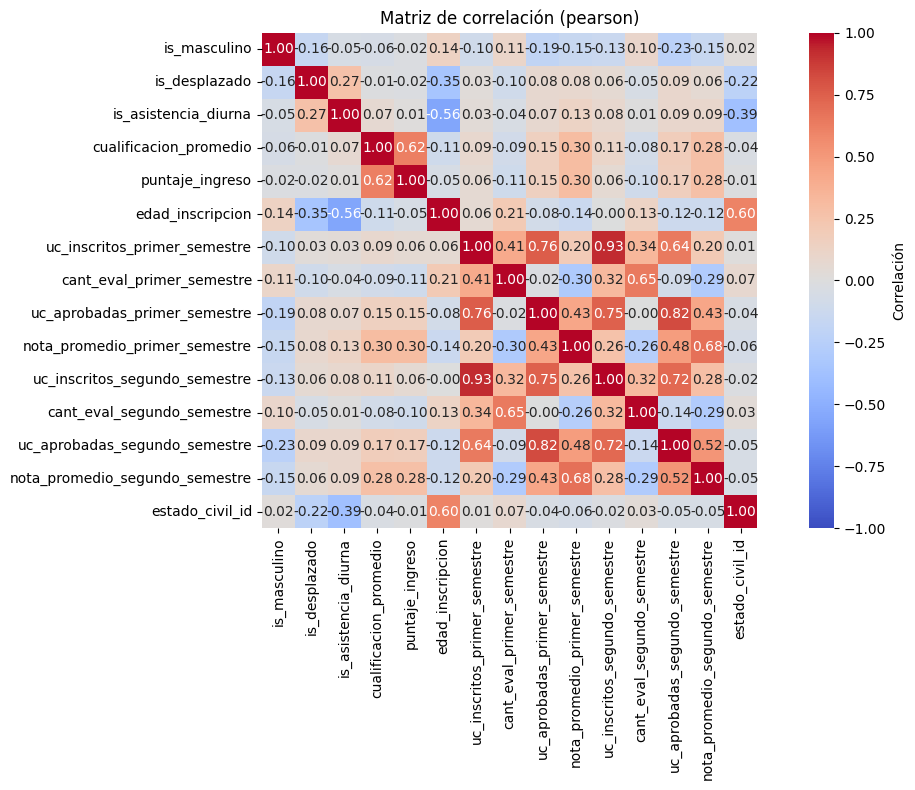

,is_masculino,is_desplazado,is_asistencia_diurna,cualificacion_promedio,puntaje_ingreso,edad_inscripcion,uc_inscritos_primer_semestre,cant_eval_primer_semestre,uc_aprobadas_primer_semestre,nota_promedio_primer_semestre,uc_inscritos_segundo_semestre,cant_eval_segundo_semestre,uc_aprobadas_segundo_semestre,nota_promedio_segundo_semestre,estado_civil_id
is_masculino,1.000000,-0.159964,-0.053190,-0.061124,-0.018130,0.137949,-0.097545,0.105721,-0.190341,-0.149264,-0.133052,0.095058,-0.231400,-0.149821,0.022316
is_desplazado,-0.159964,1.000000,0.265881,-0.009442,-0.019490,-0.346321,0.030901,-0.099954,0.075131,0.080076,0.062137,-0.047798,0.091073,0.061215,-0.223199
is_asistencia_diurna,-0.053190,0.265881,1.000000,0.068676,0.009454,-0.555468,0.034304,-0.044118,0.073673,0.125796,0.081169,0.005664,0.085960,0.088260,-0.385833
cualificacion_promedio,-0.061124,-0.009442,0.068676,1.000000,0.620736,-0.106343,0.085755,-0.090747,0.153077,0.298233,0.108963,-0.083380,0.174064,0.277455,-0.037910
puntaje_ingreso,-0.018130,-0.019490,0.009454,0.620736,1.000000,-0.052281,0.057801,-0.107841,0.152974,0.298685,0.060553,-0.100370,0.165099,0.276720,-0.011744
edad_inscripcion,0.137949,-0.346321,-0.555468,-0.106343,-0.052281,1.000000,0.056574,0.205794,-0.078598,-0.140029,-0.004338,0.132377,-0.120101,-0.119637,0.603682
uc_inscritos_primer_semestre,-0.097545,0.030901,0.034304,0.085755,0.057801,0.056574,1.000000,0.410189,0.758366,0.202013,0.926208,0.339412,0.642059,0.203546,0.011466
cant_eval_primer_semestre,0.105721,-0.099954,-0.044118,-0.090747,-0.107841,0.205794,0.410189,1.000000,-0.018664,-0.297786,0.321982,0.647562,-0.093265,-0.290122,0.072834
uc_aprobadas_primer_semestre,-0.190341,0.075131,0.073673,0.153077,0.152974,-0.078598,0.758366,-0.018664,1.000000,0.434751,0.749354,-0.002030,0.823585,0.430758,-0.044881
nota_promedio_primer_semestre,-0.149264,0.080076,0.125796,0.298233,0.298685,-0.140029,0.202013,-0.297786,0.434751,1.000000,0.262451,-0.261201,0.480077,0.684515,-0.062617


In [ ]:
matriz_correlacion = calcular_correlacion(
    dataset,
    plot=True,
)


In [7]:
pip install optbinning

     |████████████████████████████████| 214 kB 12.0 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 72.7 MB/s eta 0:00:01
     |████████████████████████████████| 20.6 MB 765 kB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 78.0 MB/s eta 0:00:01
     |████████████████████████████████| 135 kB 40.7 MB/s eta 0:00:01
     |████████████████████████████████| 404 kB 61.1 MB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 54.8 MB/s eta 0:00:01
     |████████████████████████████████| 935 kB 9.7 MB/s eta 0:00:01
     |████████████████████████████████| 234 kB 57.7 MB/s eta 0:00:01
     |████████████████████████████████| 307 kB 55.4 MB/s eta 0:00:01
  Using cached cffi-2.0.0-cp39-cp39-macosx_11_0_arm64.whl (180 kB)
     |████████████████████████████████| 309 kB 72.4 MB/s eta 0:00:01
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached pycparser-2.23-py3-none-any.whl (118 kB)
  Using cached markupsafe-3.0.3-cp39-cp39-macosx_11_0_arm64.whl

In [8]:
import pandas as pd
from optbinning import OptimalBinning

In [10]:
dataset.is_desercion.unique()

array(['Desertor', 'En Curso', 'Graduado'], dtype=object)

In [11]:
dataset_binario = dataset[dataset["is_desercion"].isin(["Desertor", "Graduado"])].copy()
dataset_binario["is_desercion"] = dataset_binario["is_desercion"].map({"Graduado": 0, "Desertor": 1})
dataset_binario["is_desercion"].value_counts()

is_desercion
1    35685
0     7738
Name: count, dtype: int64

In [17]:
dataset_binario.shape

(43423, 30)

In [55]:
def calcular_bivariado_iv(df, target_col, variables=None, plot=True):
    """
    Calcula el Information Value (IV) de variables numéricas y categóricas
    usando OptimalBinning.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame con el target y las variables a evaluar.
    target_col : str
        Nombre de la columna target binaria, codificada como 0 y 1.
    variables : list, opcional
        Columnas a evaluar. Si es None, se evalúan todas excepto el target.
    plot : bool
        Si es True, grafica el event rate por bin para cada variable.

    Returns
    -------
    pandas.DataFrame
        Tabla con variable, tipo e IV, ordenada de mayor a menor IV.
    """
    if target_col not in df.columns:
        raise KeyError(f"No existe la columna target: {target_col}")

    target = df[target_col]
    valores_target = set(target.dropna().unique())
    if not valores_target.issubset({0, 1}):
        raise ValueError("El target debe ser binario y estar codificado como 0 y 1.")

    if variables is None:
        variables = [col for col in df.columns if col != target_col]

    variables_faltantes = [col for col in variables if col not in df.columns]
    if variables_faltantes:
        raise KeyError(f"No existen estas columnas: {variables_faltantes}")

    resultados = []

    for var in variables:
        variable = df[var]
        dtype = "numerical" if pd.api.types.is_numeric_dtype(variable) else "categorical"

        try:
            optb_var = OptimalBinning(name=var, dtype=dtype, solver="cp")
            optb_var.fit(variable, target)

            binning_table = optb_var.binning_table
            binning_table.build()
            iv = float(binning_table.iv)
            resultados.append({"variable": var, "tipo": dtype, "iv": iv})

            if plot:
                binning_table.plot(
                    metric="event_rate",
                    add_special=False,
                    add_missing=False,
                    show_bin_labels=True,
                )
                plt.show()

        except Exception as error:
            print(f"Error procesando la variable '{var}': {error}")

    resultado_df = pd.DataFrame(resultados, columns=["variable", "tipo", "iv"])
    return resultado_df.sort_values("iv", ascending=False).reset_index(drop=True)

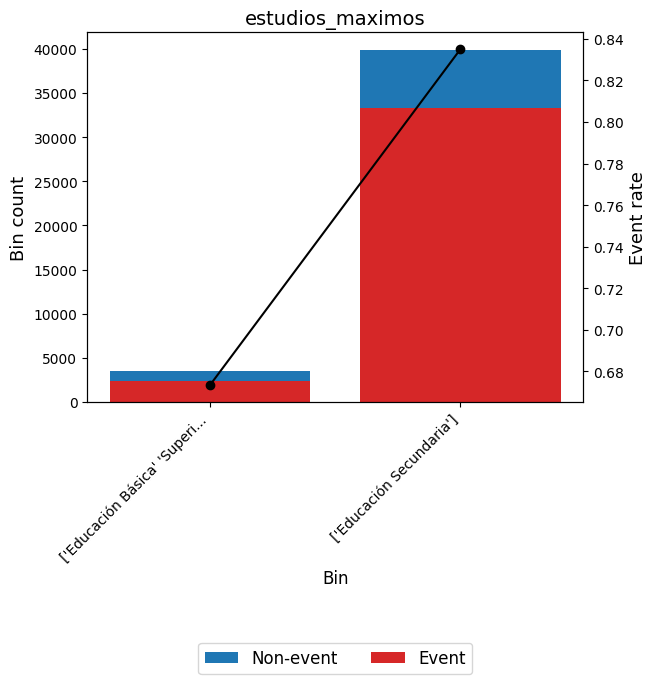

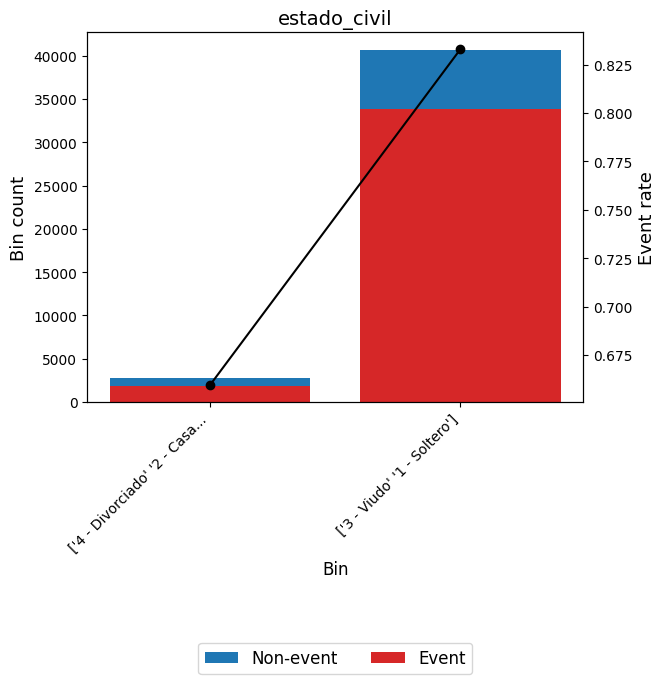

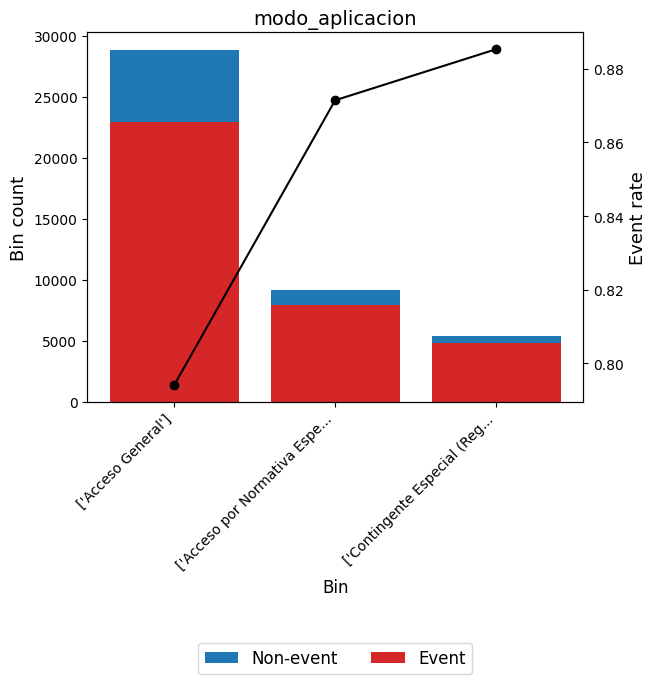

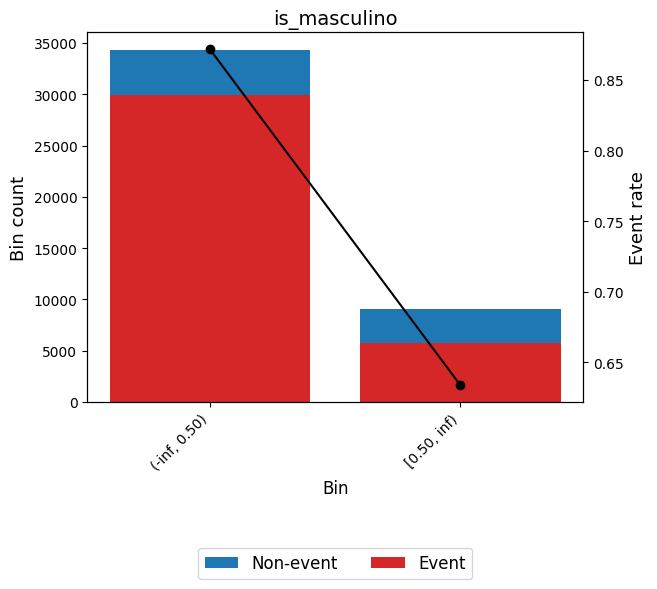

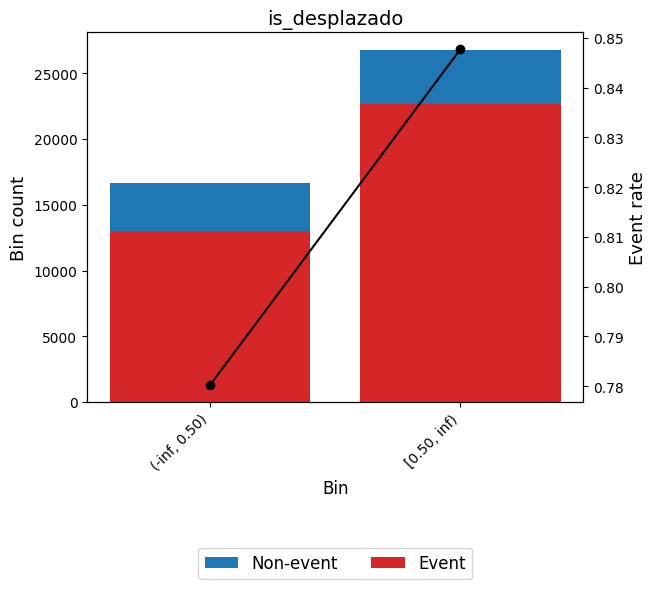

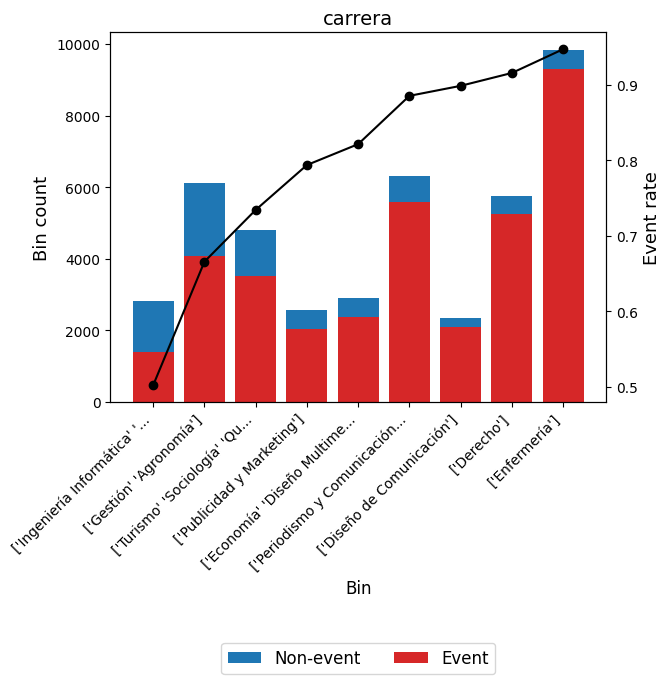

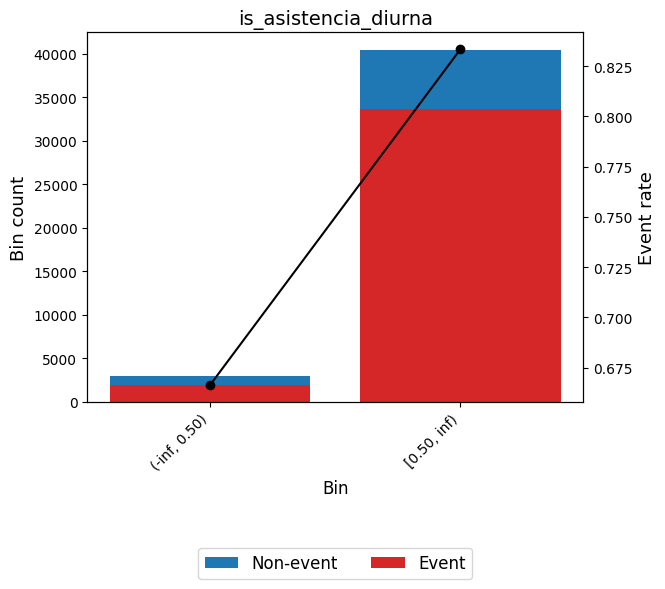

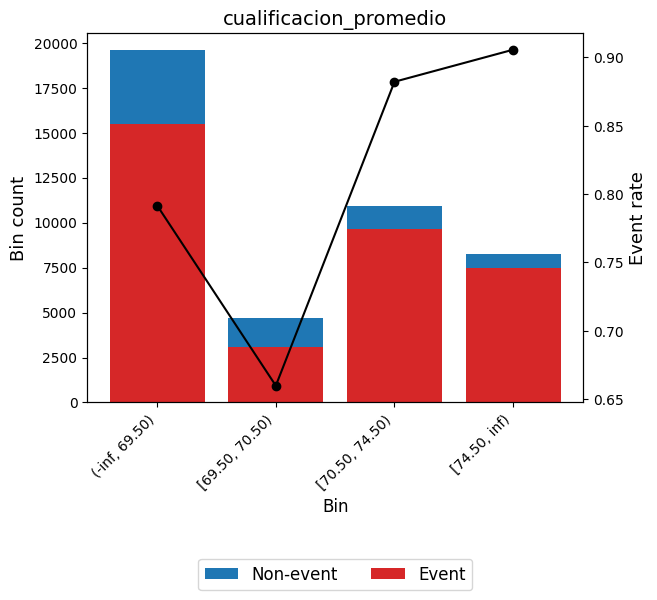

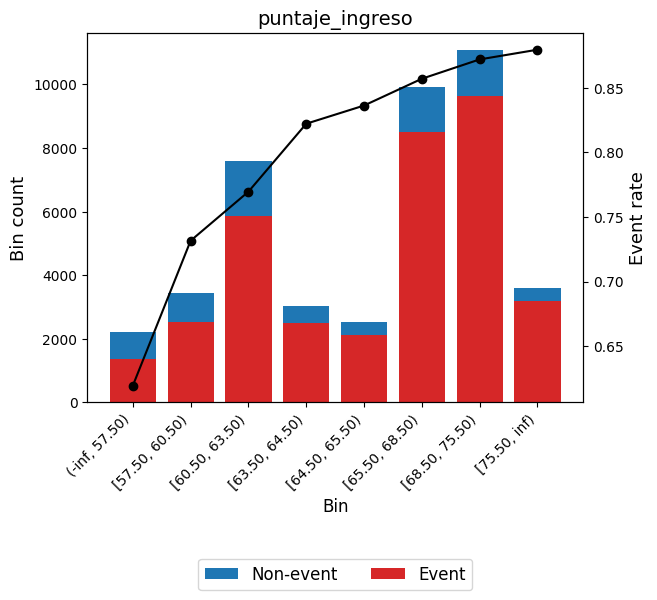

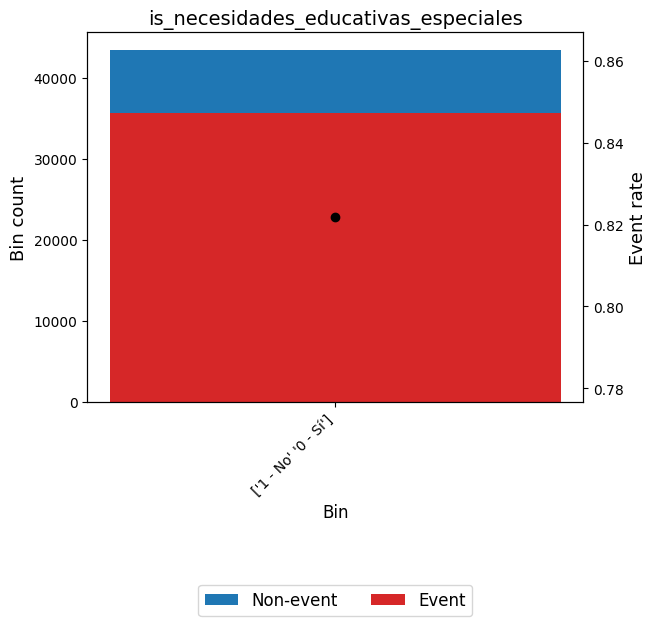

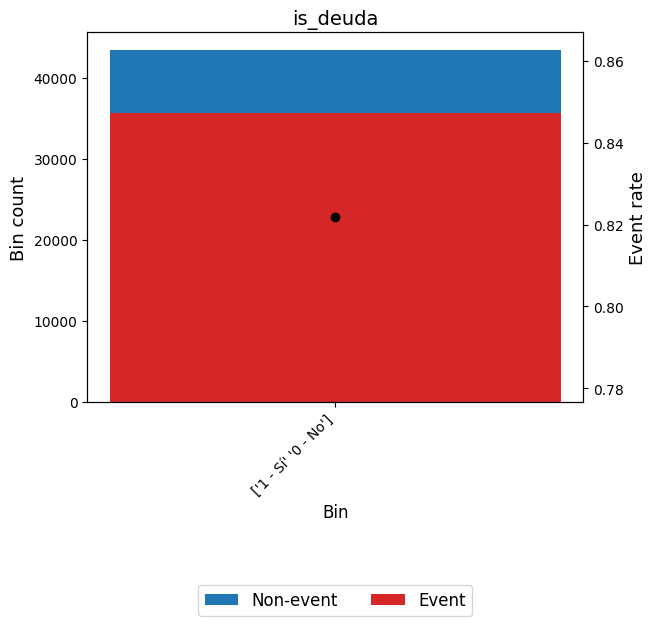

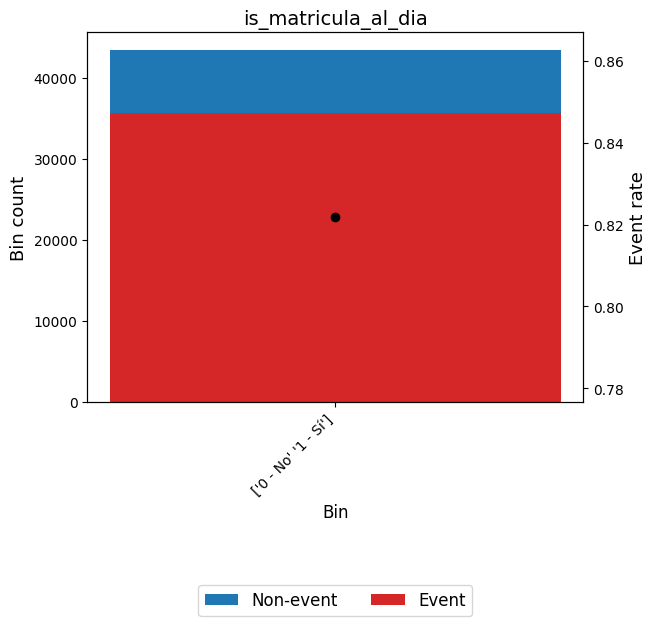

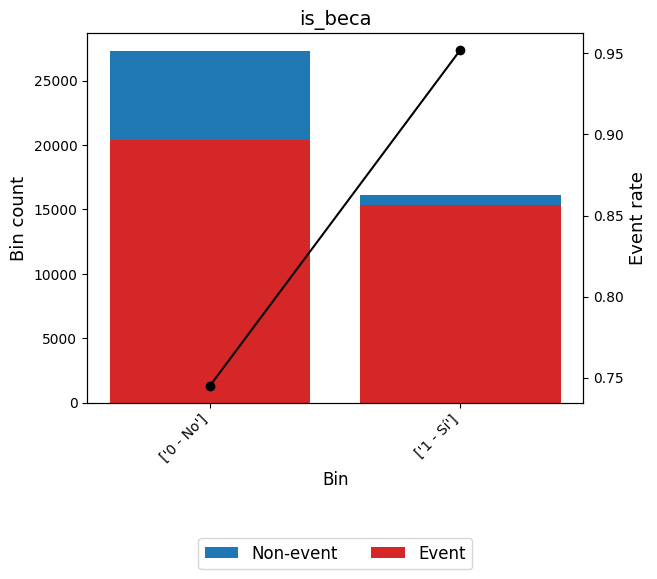

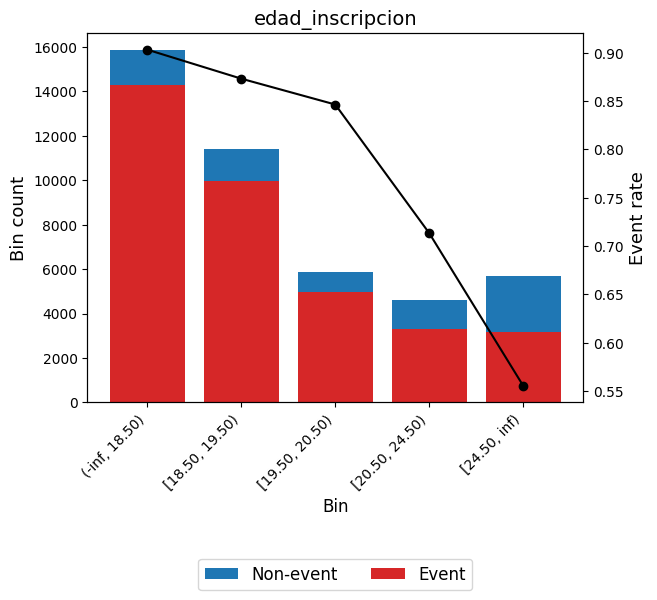

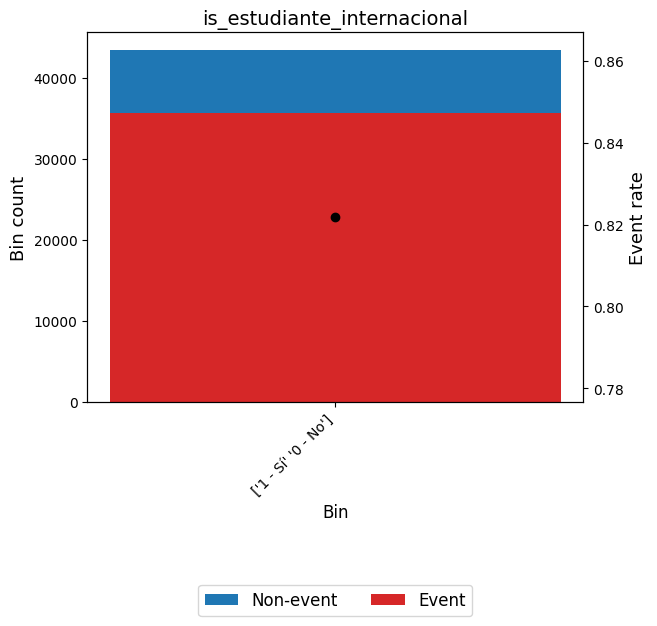

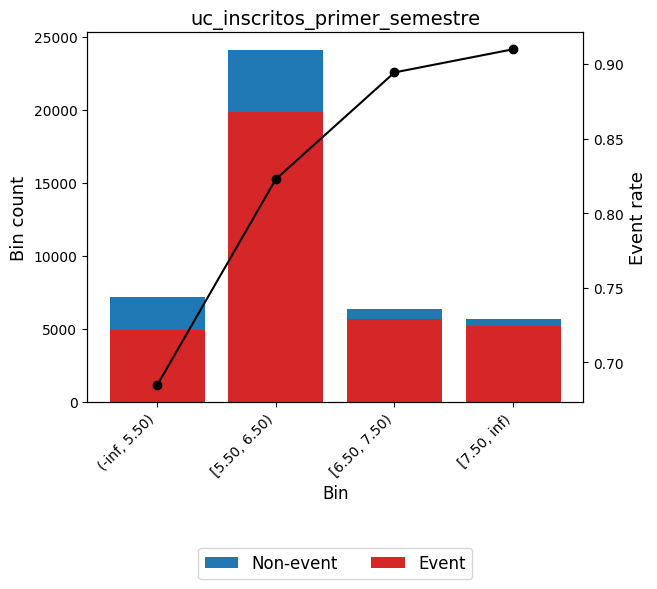

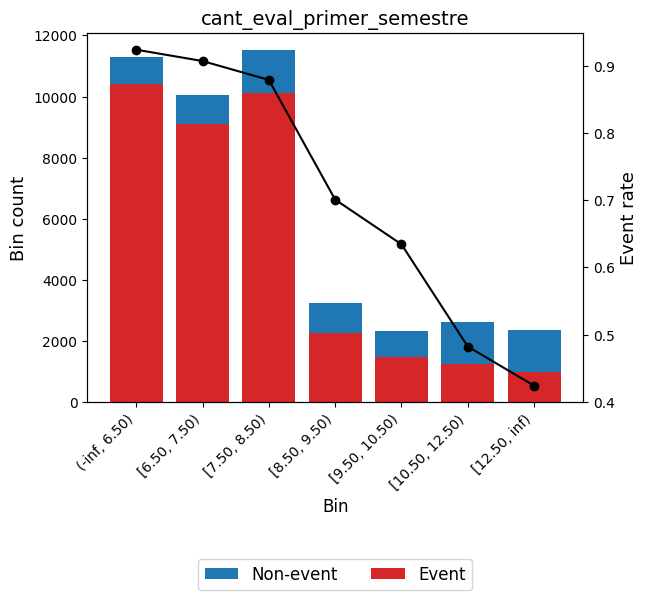

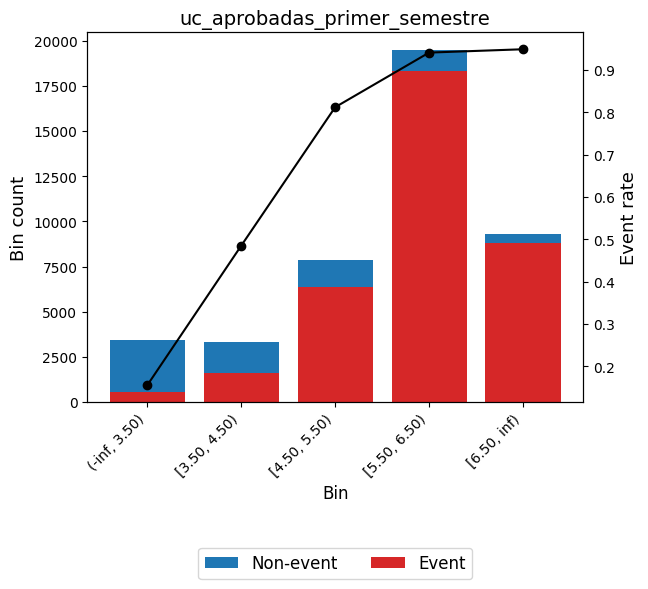

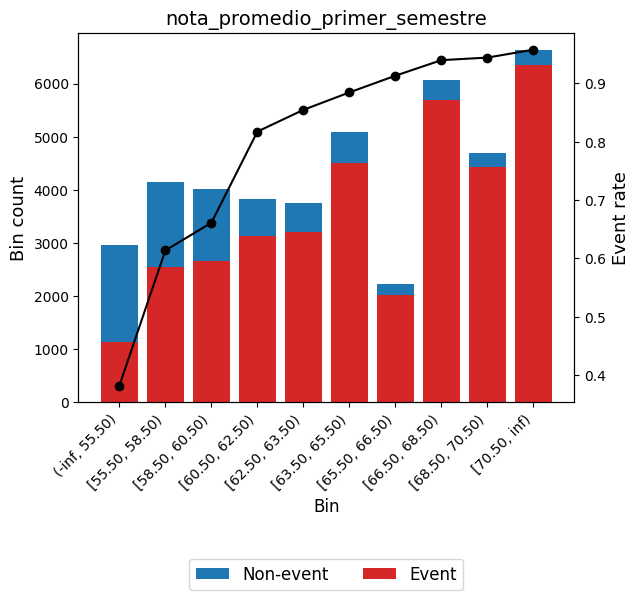

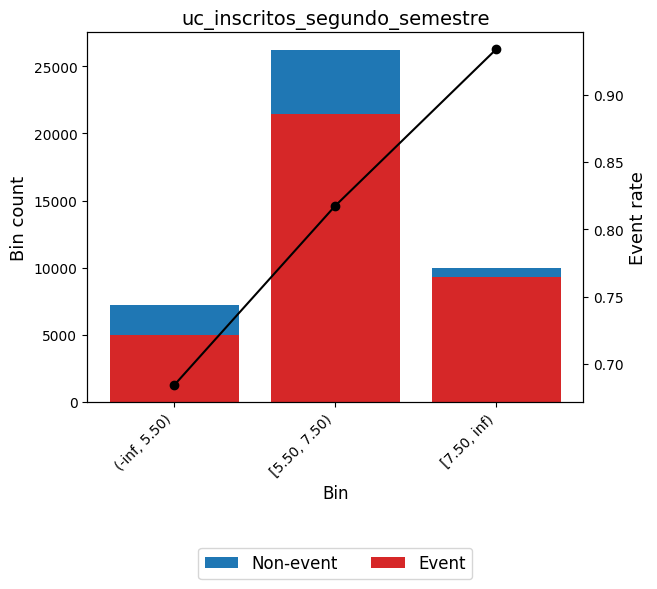

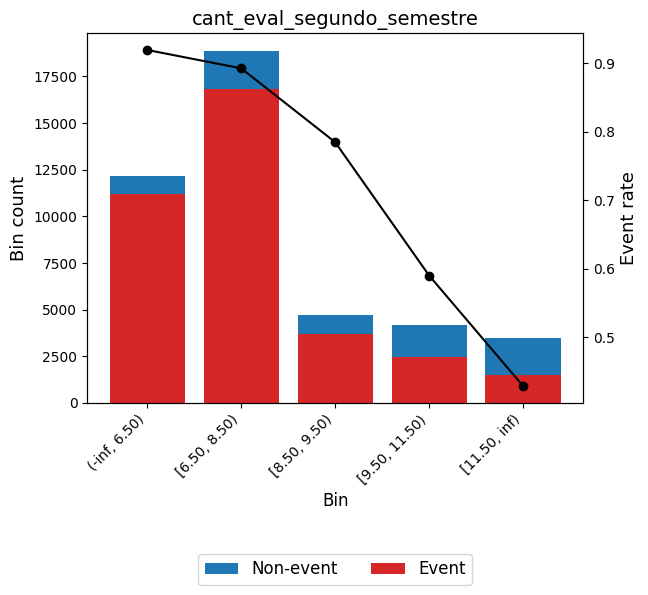

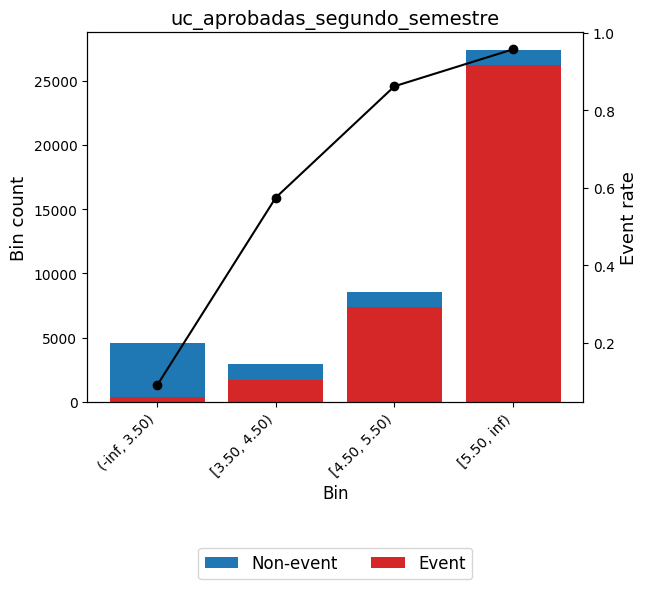

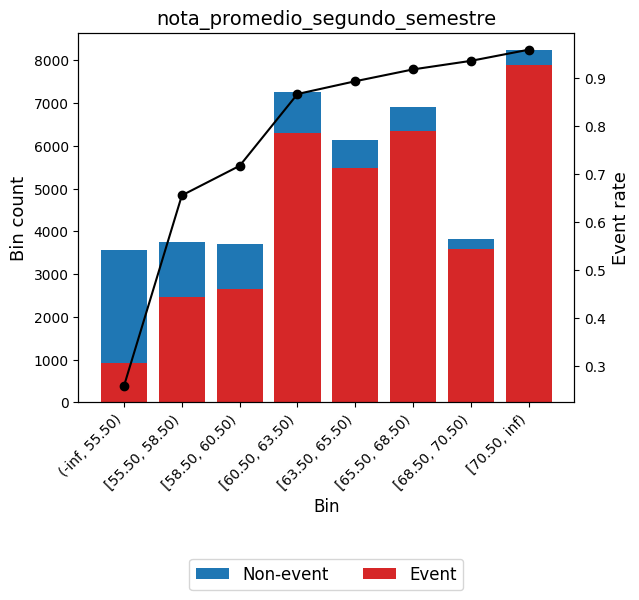

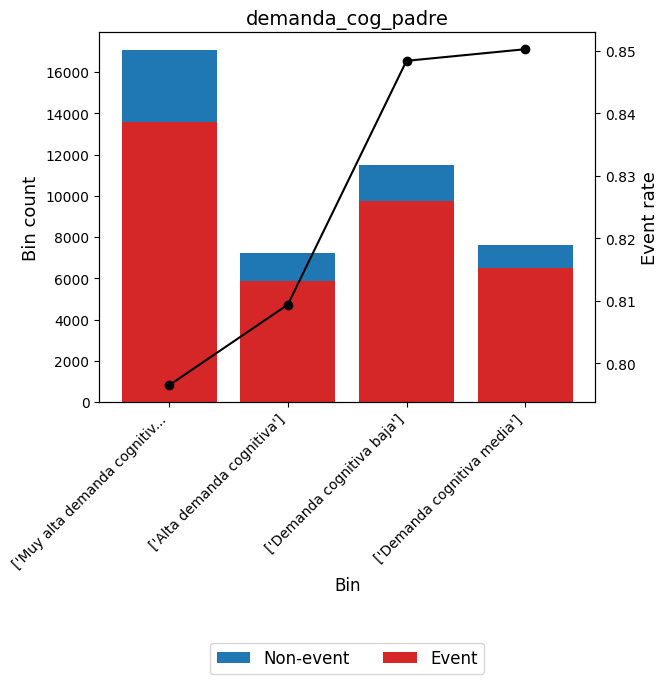

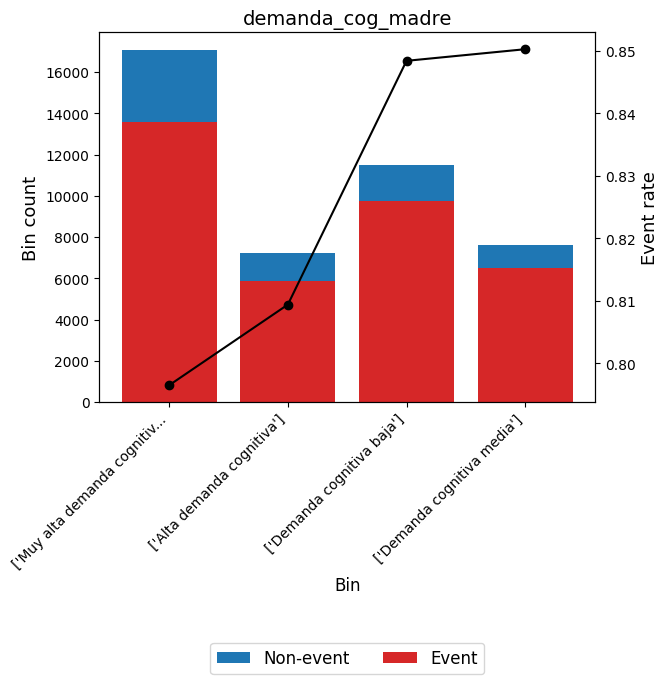

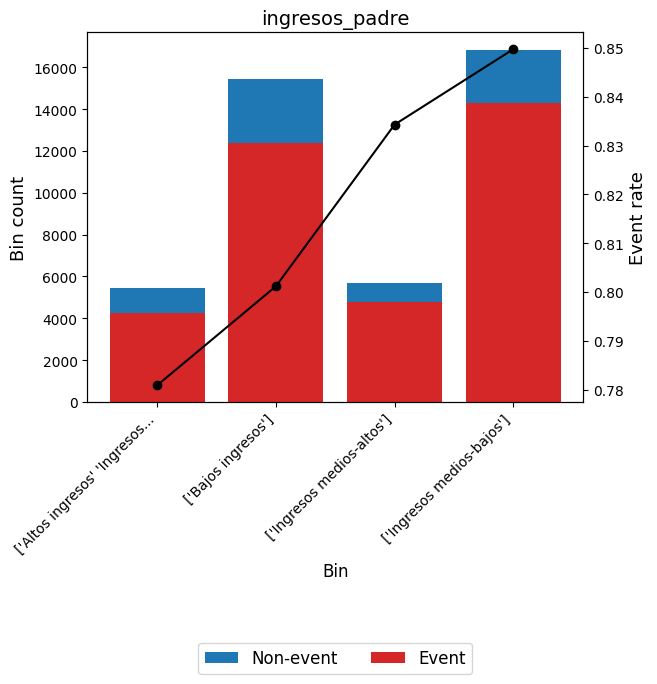

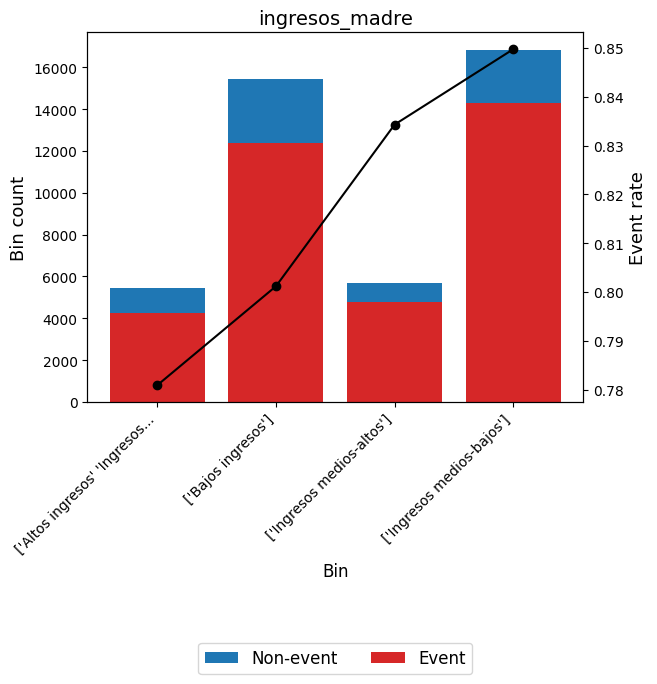

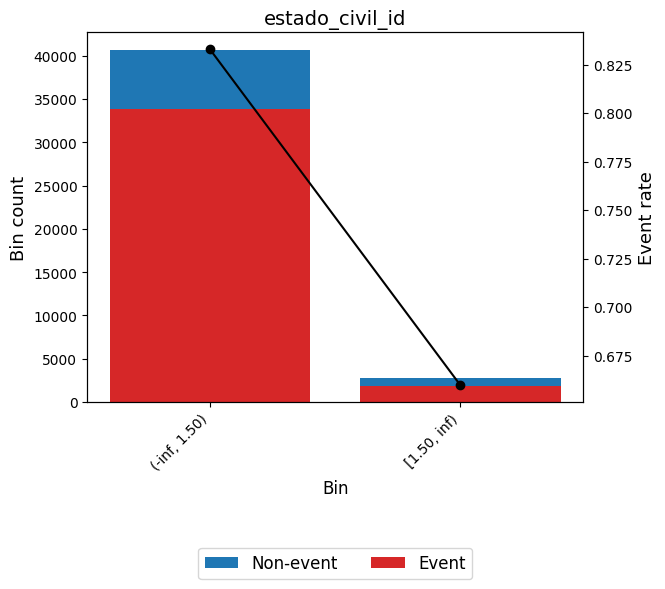

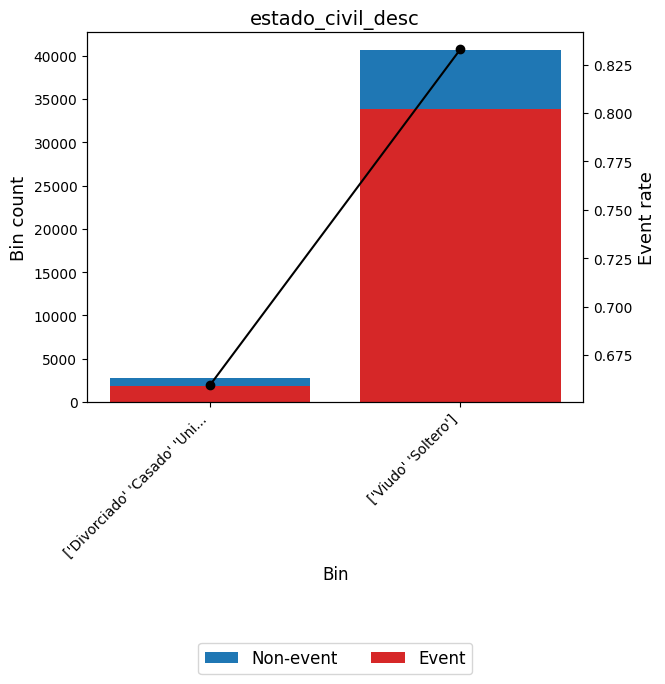

,variable,tipo,iv
0,uc_aprobadas_segundo_semestre,numerical,3.110336
1,uc_aprobadas_primer_semestre,numerical,2.149905
2,nota_promedio_segundo_semestre,numerical,1.466473
3,nota_promedio_primer_semestre,numerical,1.182226
4,cant_eval_primer_semestre,numerical,0.928337
5,cant_eval_segundo_semestre,numerical,0.866564
6,carrera,categorical,0.761979
7,is_beca,categorical,0.634122
8,edad_inscripcion,numerical,0.544692
9,is_masculino,numerical,0.368177


In [57]:
calcular_bivariado_iv(dataset_binario, 'is_desercion')


In [54]:
# Prueba con varias variables: plot=False permite validar el ranking sin abrir gráficos.
variables_prueba = [
    columna
    for columna in dataset_binario.select_dtypes(include="number").columns
    if columna != "is_desercion"
][:3]

resultado_iv_prueba = calcular_bivariado_iv(
    dataset_binario,
    target_col="is_desercion",
    variables=variables_prueba,
    plot=False,
)

resultado_iv_prueba

,variable,tipo,iv
0,is_masculino,numerical,0.368177
1,is_asistencia_diurna,numerical,0.067749
2,is_desplazado,numerical,0.049078


In [25]:
# Ejemplo con un DataFrame df
# x_var: tu variable independiente, y_var: tu variable binaria (0/1)
variable = dataset_binario["puntaje_ingreso"]
target = dataset_binario["is_desercion"]

optb = OptimalBinning(name="puntaje_ingreso", dtype="numerical", solver="cp", special_codes=None)

optb.fit(variable, target)

# Muestra la tabla de bins con WoE e IV por categoría
tabla_binning = optb.binning_table.build()
print(tabla_binning)

# Obtener el IV total de la variable
print(f"IV Total: {optb.binning_table.iv}")


                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 57.50)   2201   0.050687        838   1363    0.619264   
1       [57.50, 60.50)   3454   0.079543        927   2527    0.731616   
2       [60.50, 63.50)   7605   0.175138       1752   5853    0.769625   
3       [63.50, 64.50)   3044   0.070101        541   2503    0.822273   
4       [64.50, 65.50)   2530   0.058264        414   2116    0.836364   
5       [65.50, 68.50)   9911   0.228243       1416   8495    0.857128   
6       [68.50, 75.50)  11064   0.254796       1415   9649    0.872108   
7         [75.50, inf)   3614   0.083228        435   3179    0.879635   
8              Special      0   0.000000          0      0    0.000000   
9              Missing      0   0.000000          0      0    0.000000   
Totals                  43423   1.000000       7738  35685    0.821800   

             WoE            IV            JS  
0       1.042162  7.305700e-02  8.740072e-03  
1       0.525753 

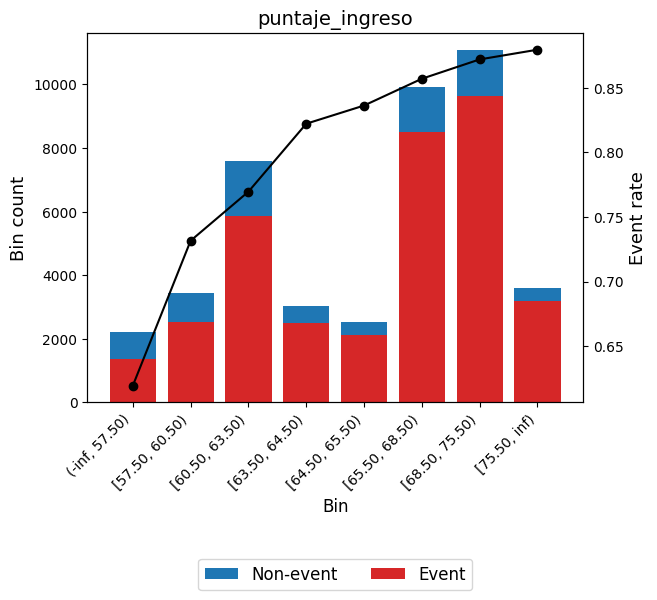

In [30]:
binning_table = optb.binning_table
binning_table.plot(metric="event_rate", add_special=False, add_missing=False, show_bin_labels=True)

plt.show()